# ApexPlanet Data Analytics Internship - Task 2
## PART 3: Multivariate Analysis & Correlation

Corrected to match the actual columns present in `cleaned_dataset.csv`:
- `Avg_Price_Per_Unit` does not exist → removed from the correlation matrix
- `Revenue_Tier` does not exist → replaced with `Revenue_Category` (3 tiers: `Low_Revenue`, `Medium_Revenue`, `High_Revenue`)
- No `'Unknown'` city in this dataset → removed the dead filter
- Output path made relative (`./charts`) so it works in any environment, including VS Code


In [ ]:
"""
ApexPlanet Data Analytics Internship - Task 2
PART 3: Multivariate Analysis & Correlation
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv('cleaned_dataset.csv')

# Relative output folder — works in VS Code, Jupyter, or any local environment
OUT = './charts'
os.makedirs(OUT, exist_ok=True)

COLORS = ['#2E75B6', '#F4B942', '#70AD47', '#C0504D', '#8064A2']


## Correlation Matrix


In [ ]:
# ─────────────────────────────────────────────
# CORRELATION MATRIX
# ─────────────────────────────────────────────
# Avg_Price_Per_Unit does not exist in this dataset — removed.
num_cols = ['Age', 'Quantity', 'Unit_Price', 'Total_Sales']
corr = df[num_cols].corr()
print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)
print(corr.round(3))


CORRELATION MATRIX
               Age  Quantity  Unit_Price  Total_Sales
Age          1.000    -0.028      -0.012        0.001
Quantity    -0.028     1.000       0.022        0.647
Unit_Price  -0.012     0.022       1.000        0.686
Total_Sales  0.001     0.647       0.686        1.000


## Chart 11: Correlation Heatmap


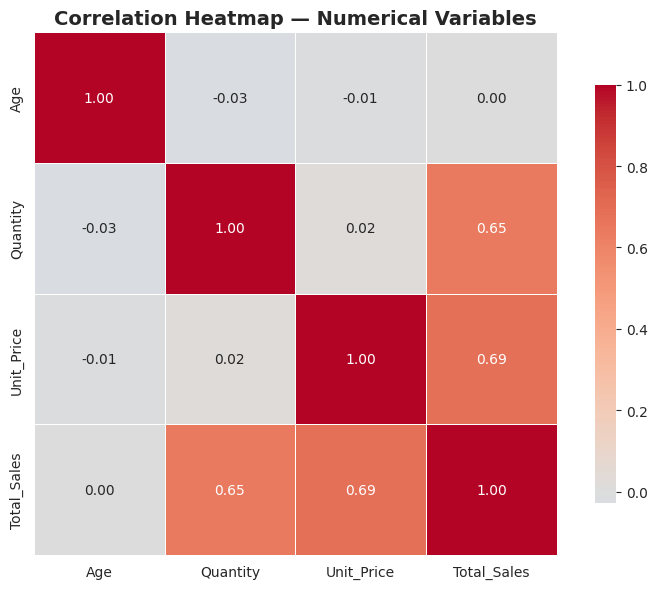

In [ ]:
# ─────────────────────────────────────────────
# CHART 11: Correlation Heatmap
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/11_correlation_heatmap.png', dpi=150)
plt.show()


## Chart 12: Scatter — Quantity vs Total_Sales


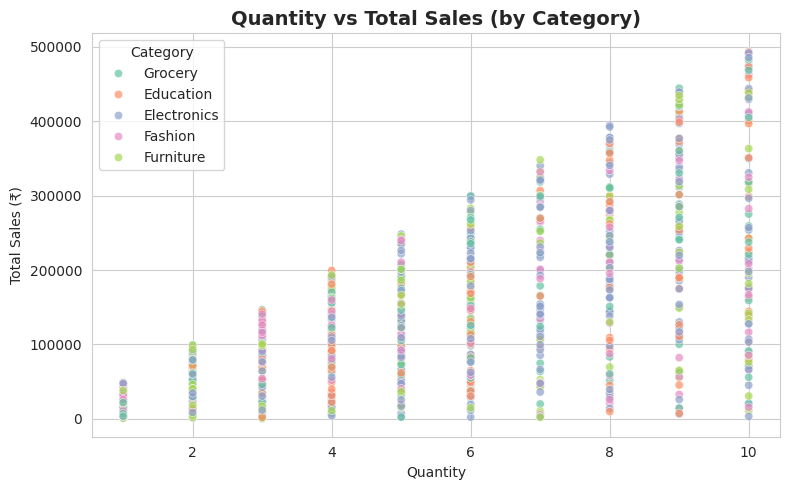

In [ ]:
# ─────────────────────────────────────────────
# CHART 12: Scatter — Quantity vs Total_Sales
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='Quantity', y='Total_Sales', hue='Category',
                 palette='Set2', alpha=0.7, ax=ax)
ax.set_title('Quantity vs Total Sales (by Category)', fontsize=14, fontweight='bold')
ax.set_xlabel('Quantity'); ax.set_ylabel('Total Sales (₹)')
plt.tight_layout()
plt.savefig(f'{OUT}/12_scatter_quantity_vs_sales.png', dpi=150)
plt.show()


## Chart 13: Scatter — Age vs Total_Sales


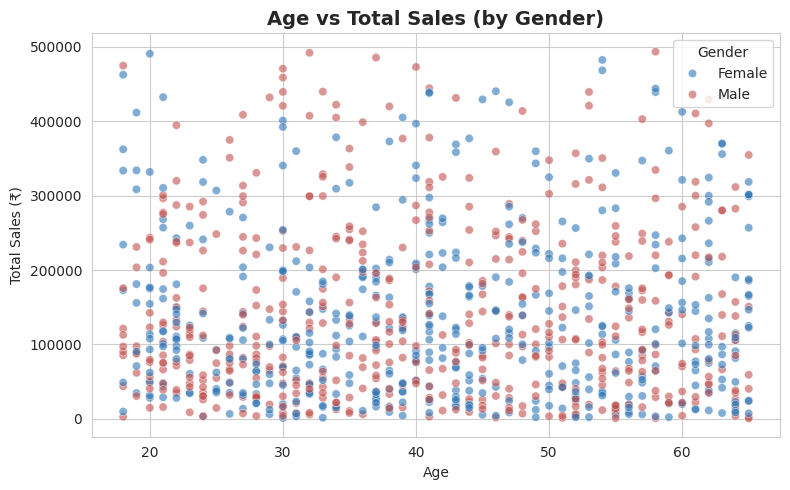

In [ ]:
# ─────────────────────────────────────────────
# CHART 13: Scatter — Age vs Total_Sales
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Total_Sales', hue='Gender',
                 palette=[COLORS[0], COLORS[3]], alpha=0.6, ax=ax)
ax.set_title('Age vs Total Sales (by Gender)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age'); ax.set_ylabel('Total Sales (₹)')
plt.tight_layout()
plt.savefig(f'{OUT}/13_scatter_age_vs_sales.png', dpi=150)
plt.show()


## Chart 14: Box Plot — Age vs Category


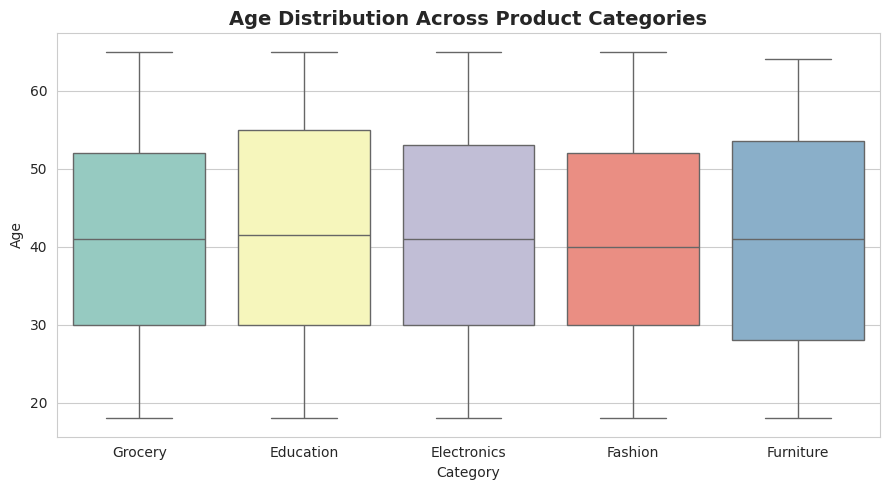

In [ ]:
# ─────────────────────────────────────────────
# CHART 14: Box Plot — Age vs Category (does age vary by category?)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Category', y='Age', hue='Category', palette='Set3', ax=ax, legend=False)
ax.set_title('Age Distribution Across Product Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Category'); ax.set_ylabel('Age')
plt.tight_layout()
plt.savefig(f'{OUT}/14_boxplot_age_by_category.png', dpi=150)
plt.show()


## Chart 15: Box Plot — Total_Sales by Revenue Category x Gender

**Fixed:** `Revenue_Tier` does not exist in this dataset. The real column is `Revenue_Category` with three tiers (`Low_Revenue`, `Medium_Revenue`, `High_Revenue`), not four.


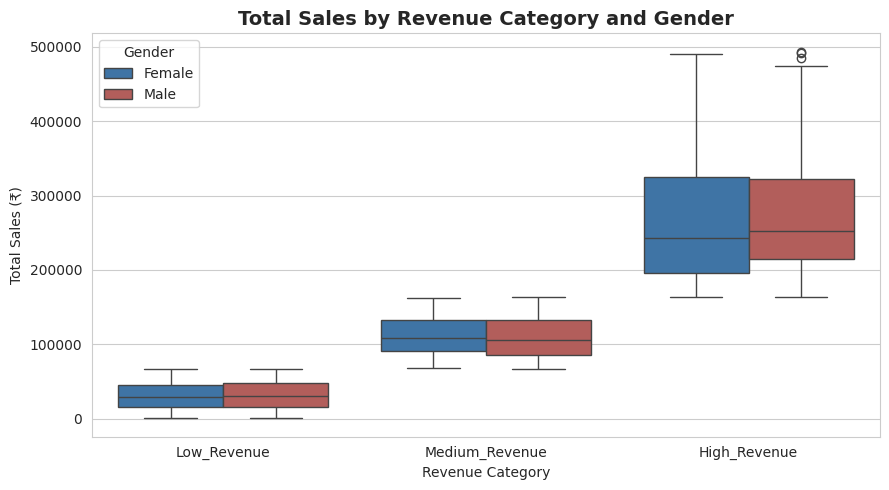

In [ ]:
# ─────────────────────────────────────────────
# CHART 15: Box Plot — Total_Sales by Revenue_Category x Gender
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
tier_order = ['Low_Revenue', 'Medium_Revenue', 'High_Revenue']
sns.boxplot(data=df, x='Revenue_Category', y='Total_Sales', hue='Gender',
            order=tier_order, palette=[COLORS[0], COLORS[3]], ax=ax)
ax.set_title('Total Sales by Revenue Category and Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue Category'); ax.set_ylabel('Total Sales (₹)')
plt.tight_layout()
plt.savefig(f'{OUT}/15_boxplot_sales_category_gender.png', dpi=150)
plt.show()


## Chart 16: Heatmap — City x Category Revenue

**Fixed:** removed the `City != 'Unknown'` filter — this dataset has no `'Unknown'` city values, so the filter was dead code.


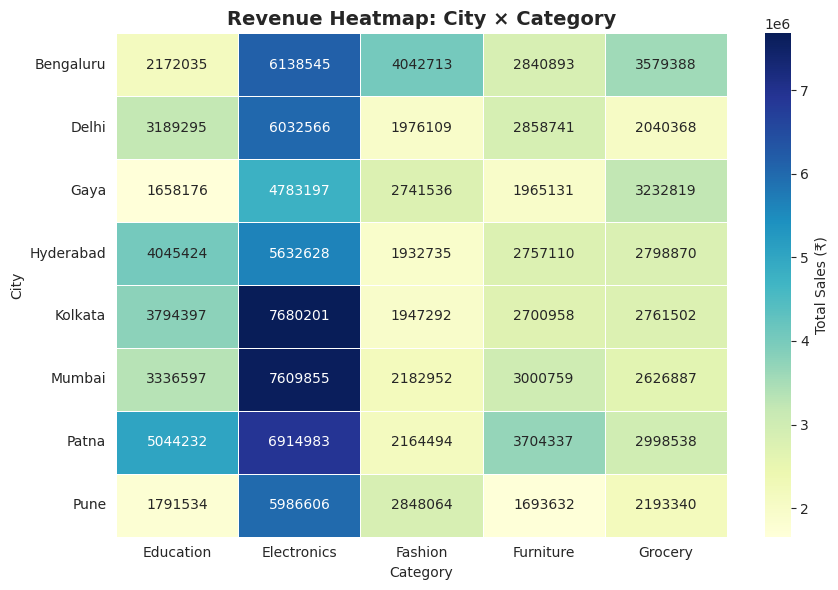

In [ ]:
# ─────────────────────────────────────────────
# CHART 16: Heatmap — City x Category Revenue
# ─────────────────────────────────────────────
pivot = df.pivot_table(
    index='City', columns='Category', values='Total_Sales', aggfunc='sum', fill_value=0)
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Total Sales (₹)'})
ax.set_title('Revenue Heatmap: City × Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/16_heatmap_city_category.png', dpi=150)
plt.show()


## Chart 17: Pair Plot


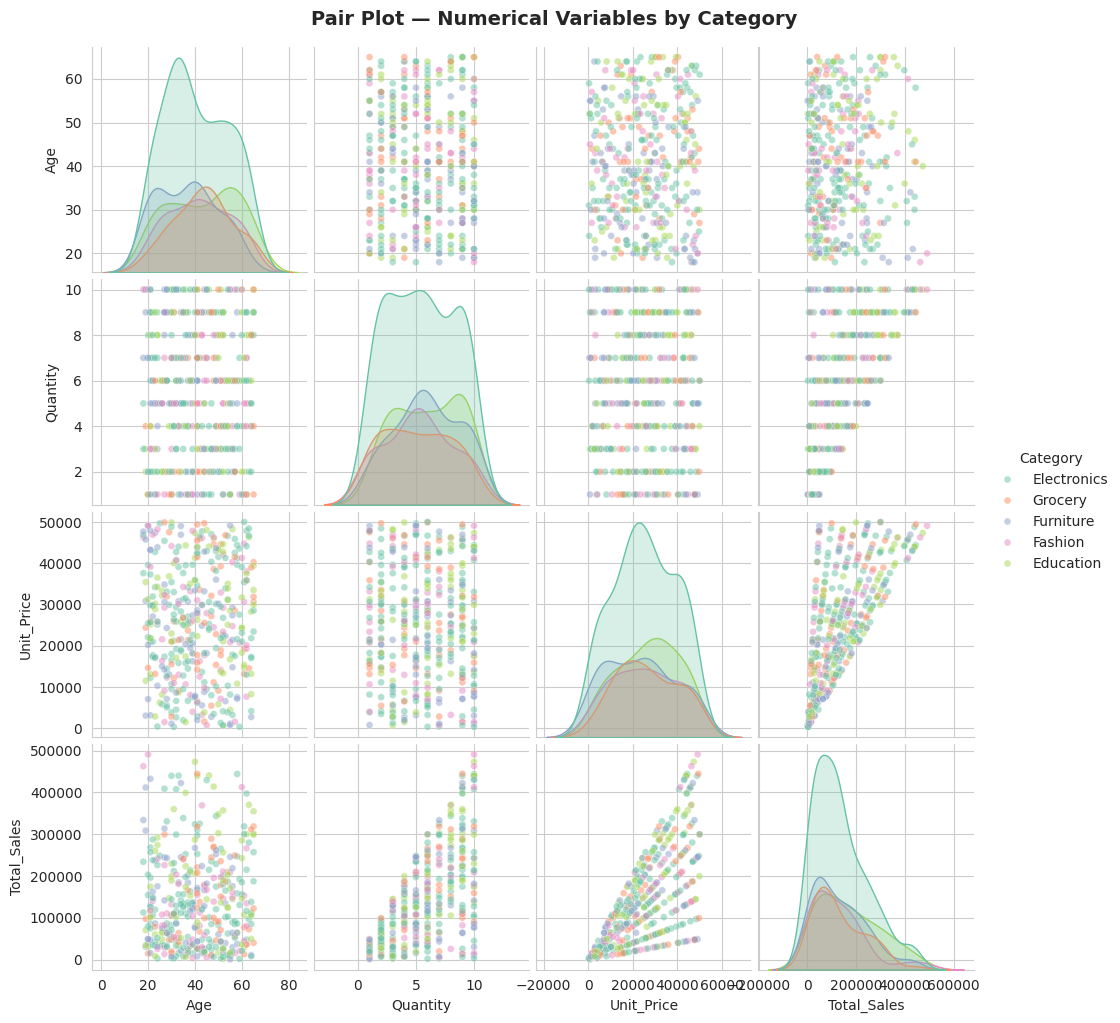

In [ ]:
# ─────────────────────────────────────────────
# CHART 17: Pair Plot — Age, Quantity, Unit_Price, Total_Sales
# ─────────────────────────────────────────────
pair_df = df[['Age', 'Quantity', 'Unit_Price', 'Total_Sales', 'Category']].sample(
    n=min(400, len(df)), random_state=42)
g = sns.pairplot(pair_df, hue='Category', palette='Set2', diag_kind='kde',
                  plot_kws={'alpha': 0.5, 's': 25})
g.fig.suptitle('Pair Plot — Numerical Variables by Category', y=1.02, fontsize=14, fontweight='bold')
g.savefig(f'{OUT}/17_pairplot.png', dpi=150)
plt.show()


## Chart 18: Grouped Bar — Avg Order Value by Age Group x Category


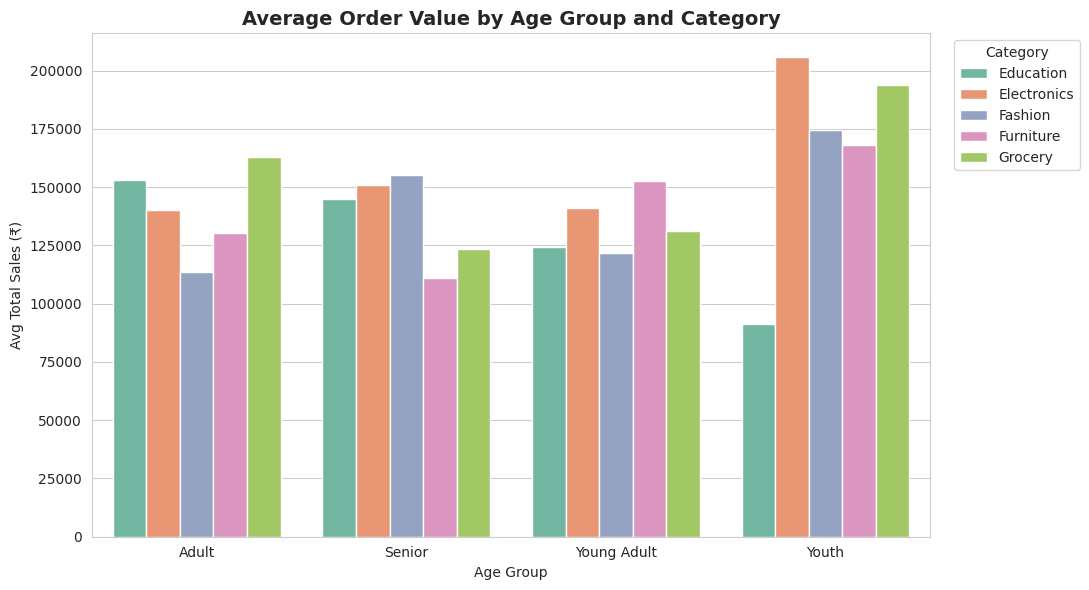

In [ ]:
# ─────────────────────────────────────────────
# CHART 18: Grouped Bar — Avg Order Value by Age_Group x Category
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
grp = df.groupby(['Age_Group', 'Category'])['Total_Sales'].mean().reset_index()
sns.barplot(data=grp, x='Age_Group', y='Total_Sales', hue='Category', palette='Set2', ax=ax)
ax.set_title('Average Order Value by Age Group and Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group'); ax.set_ylabel('Avg Total Sales (₹)')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{OUT}/18_avg_order_value_age_category.png', dpi=150)
plt.show()


## Key Insights from Correlation


In [ ]:
# ─────────────────────────────────────────────
# KEY INSIGHTS FROM CORRELATION
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("KEY MULTIVARIATE INSIGHTS")
print("=" * 60)
print(f"""
1. Quantity vs Total_Sales correlation: {corr.loc['Quantity','Total_Sales']:.3f}
   -> {'Strong' if abs(corr.loc['Quantity','Total_Sales'])>0.5 else 'Weak/Moderate'} positive relationship — more units ordered drives higher revenue.

2. Unit_Price vs Total_Sales correlation: {corr.loc['Unit_Price','Total_Sales']:.3f}
   -> {'Strong' if abs(corr.loc['Unit_Price','Total_Sales'])>0.5 else 'Weak/Moderate'} relationship — price point also drives revenue, alongside quantity.

3. Age vs Total_Sales correlation: {corr.loc['Age','Total_Sales']:.3f}
   -> Negligible — customer age has little linear relationship with order value.

4. Age vs Unit_Price correlation: {corr.loc['Age','Unit_Price']:.3f}
   -> Negligible — older customers don't systematically buy higher or lower-priced items.
""")





KEY MULTIVARIATE INSIGHTS

1. Quantity vs Total_Sales correlation: 0.647
   -> Strong positive relationship — more units ordered drives higher revenue.

2. Unit_Price vs Total_Sales correlation: 0.686
   -> Strong relationship — price point also drives revenue, alongside quantity.

3. Age vs Total_Sales correlation: 0.001
   -> Negligible — customer age has little linear relationship with order value.

4. Age vs Unit_Price correlation: -0.012
   -> Negligible — older customers don't systematically buy higher or lower-priced items.

✅ 8 multivariate/correlation charts saved to ./charts
